In [16]:
import os
from dotenv import load_dotenv
from sentinelhub import SHConfig

load_dotenv()

config = SHConfig()
config.sh_client_id = os.getenv("SH_CLIENT_ID")
config.sh_client_secret = os.getenv("SH_CLIENT_SECRET")
config.sh_base_url = "https://sh.dataspace.copernicus.eu"
config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"

print("Client ID loaded:", config.sh_client_id[:8], "...")

Client ID loaded: sh-2b3f7 ...


In [17]:
import numpy as np
from sentinelhub import BBox, CRS, bbox_to_dimensions

prague_bbox = BBox(
    bbox=[14.22, 49.94, 14.71, 50.18],
    crs=CRS.WGS84
)

resolution = 60
prague_size = bbox_to_dimensions(prague_bbox, resolution=resolution)

print(f"Image size: {prague_size} px")

Image size: (588, 441) px


In [18]:
from sentinelhub import SentinelHubRequest, DataCollection, MimeType
import datetime

evalscript_ndvi = """
//VERSION=3
function setup() {
    return {
        input: ["B04", "B08", "dataMask"],
        output: { bands: 1, sampleType: "FLOAT32" }
    };
}

function evaluatePixel(sample) {
    let ndvi = (sample.B08 - sample.B04) / (sample.B08 + sample.B04);
    return [ndvi];
}
"""

request_ndvi = SentinelHubRequest(
    evalscript=evalscript_ndvi,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=DataCollection.SENTINEL2_L2A.define_from(
                "s2l2a",
                service_url="https://sh.dataspace.copernicus.eu"
            ),
            time_interval=("2024-07-01", "2024-07-31"),
            mosaicking_order="leastCC"
        )
    ],
    responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
    bbox=prague_bbox,
    size=prague_size,
    config=config
)

ndvi_data = request_ndvi.get_data()[0]
print(f"NDVI shape: {ndvi_data.shape}")
print(f"NDVI min: {ndvi_data.min():.3f}, max: {ndvi_data.max():.3f}")

NDVI shape: (441, 588)
NDVI min: -1.000, max: 0.969


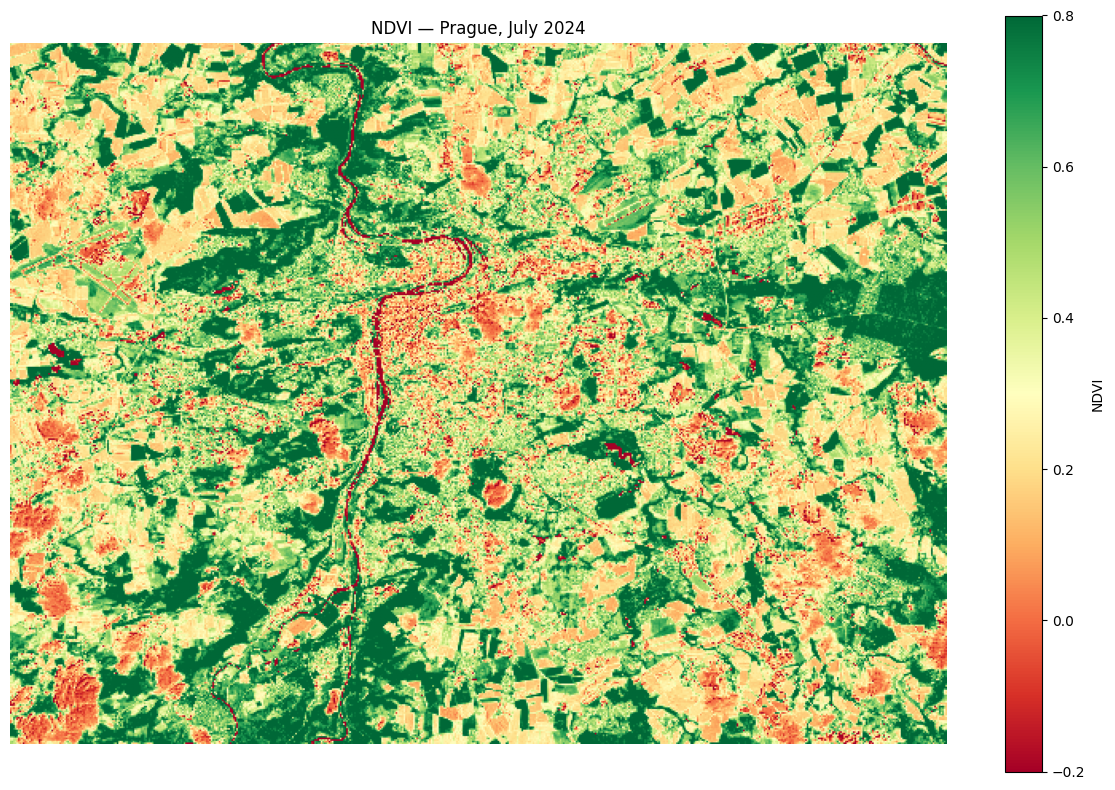

Mean NDVI: 0.434


In [19]:
import matplotlib.pyplot as plt
import numpy as np

ndvi = ndvi_data.copy()
ndvi[ndvi < -1] = np.nan

plt.figure(figsize=(12, 8))
plt.imshow(ndvi, cmap="RdYlGn", vmin=-0.2, vmax=0.8)
plt.colorbar(label="NDVI")
plt.title("NDVI — Prague, July 2024")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"Mean NDVI: {np.nanmean(ndvi):.3f}")

In [20]:
evalscript_lst = """
//VERSION=3
function setup() {
    return {
        input: ["S7"],
        output: { bands: 1, sampleType: "FLOAT32" }
    };
}

function evaluatePixel(sample) {
    // S7 is in Kelvin - convert to Celsius
    return [sample.S7 - 273.15];
}
"""

request_lst = SentinelHubRequest(
    evalscript=evalscript_lst,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=DataCollection.SENTINEL3_SLSTR.define_from(
                "s3slstr",
                service_url="https://sh.dataspace.copernicus.eu"
            ),
            time_interval=("2024-07-01", "2024-07-31"),
        )
    ],
    responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
    bbox=prague_bbox,
    size=prague_size,
    config=config
)

lst_data = request_lst.get_data()[0]
print(f"LST shape: {lst_data.shape}")
print(f"LST min: {lst_data.min():.2f}°C")
print(f"LST max: {lst_data.max():.2f}°C")
print(f"LST mean: {lst_data.mean():.2f}°C")

LST shape: (441, 588)
LST min: 4.87°C
LST max: 15.26°C
LST mean: 10.74°C


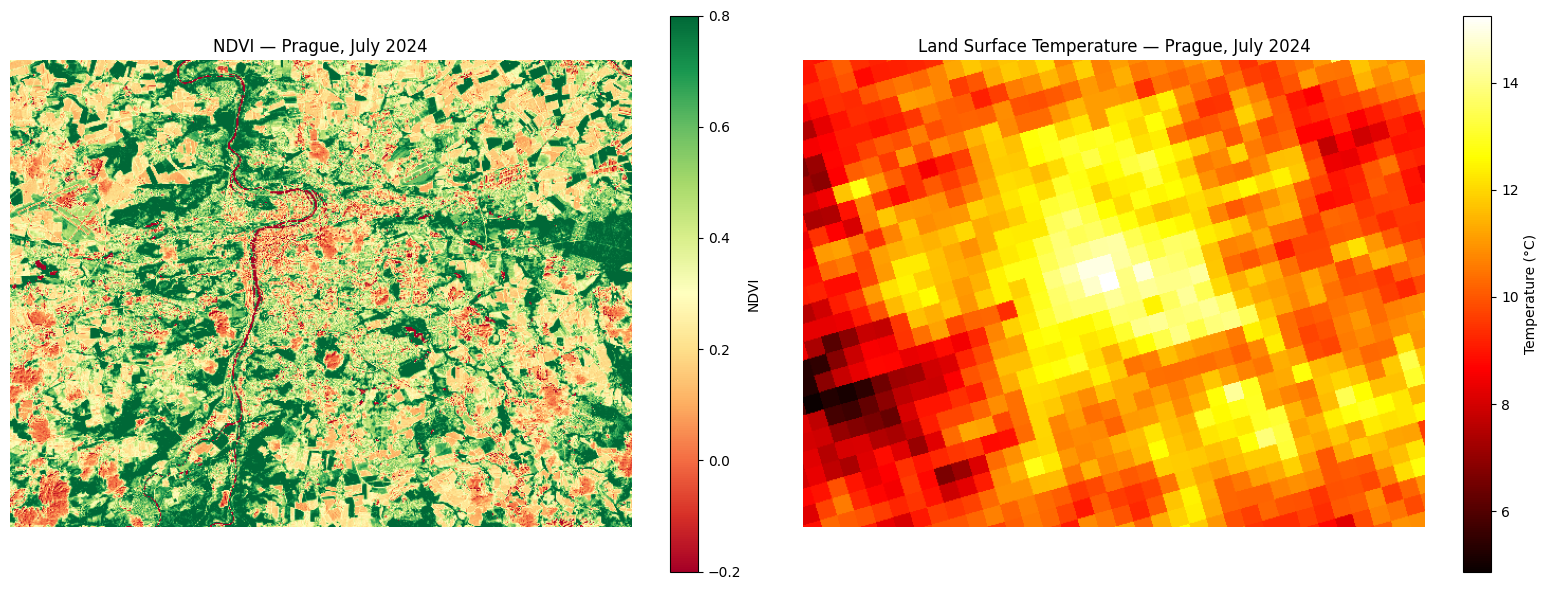

Mean NDVI: 0.434
Mean LST: 10.74°C


In [21]:
import matplotlib.pyplot as plt
import numpy as np

lst = lst_data.copy()
lst[lst == 0] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# NDVI map
im1 = axes[0].imshow(ndvi, cmap="RdYlGn", vmin=-0.2, vmax=0.8)
axes[0].set_title("NDVI — Prague, July 2024")
axes[0].axis("off")
plt.colorbar(im1, ax=axes[0], label="NDVI")

# LST map
im2 = axes[1].imshow(lst, cmap="hot", vmin=lst.min(), vmax=lst.max())
axes[1].set_title("Land Surface Temperature — Prague, July 2024")
axes[1].axis("off")
plt.colorbar(im2, ax=axes[1], label="Temperature (°C)")

plt.tight_layout()
plt.show()

print(f"Mean NDVI: {np.nanmean(ndvi):.3f}")
print(f"Mean LST: {np.nanmean(lst):.2f}°C")

In [22]:
import numpy as np
import os

# Create data directory if it doesn't exist
os.makedirs("data", exist_ok=True)

# Save raw arrays to disk
np.save("data/ndvi_prague_july2024.npy", ndvi)
np.save("data/lst_prague_july2024.npy", lst)

print("Data saved successfully!")
print(f"NDVI: {ndvi.shape} -> data/ndvi_prague_july2024.npy")
print(f"LST:  {lst.shape} -> data/lst_prague_july2024.npy")

Data saved successfully!
NDVI: (441, 588) -> data/ndvi_prague_july2024.npy
LST:  (441, 588) -> data/lst_prague_july2024.npy
